# Advanced Solar Activity Forecasting: Mathematical Framework
### Integration of PVL Parametrics, Adaptive Kalman Filtering, and Dynamic Mode Decomposition (DMD)

This report formalizes the predictive engine used for sunspot number (SSN) and latitudinal migration analysis. We combine physical heuristics based on the Podladchikova-Van der Linden (PVL) model with data-driven operator theory to provide robust forecasts for Solar Cycle 25 and beyond.

In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Publication Style Configuration
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#334155',
    'grid.alpha': 0.15,
    'font.family': 'serif',
    'legend.frameon': True,
    'legend.edgecolor': '#e2e8f0'
})

COLORS = {'obs': '#64748b', 'kalman': '#10b981', 'dmd': '#8b5cf6', 'future_bg': '#f0fdf4'}

## 1. Discretization and Vectorization via Latitudinal Binning

To analyze the Spörer diagram mathematically, we transform individual sunspot observations into a time-series of state vectors. Let $N_{\text{spots}}(t)$ be the total number of sunspots observed at time $t$, and $\theta_i$ be the heliographic latitude of the $i$-th sunspot. Given the domain $\theta \in [-50^\circ, 50^\circ]$, we define a discretization into $M=25$ bins of size $\Delta \theta = 4^\circ$ using grid points $\theta_j$:

$$V_j(t) = \sum_{i=1}^{N_{\text{spots}}(t)} \mathbb{1}_{\mathcal{B}_j}(\theta_i)$$

where $\mathcal{B}_j = [\theta_j, \theta_{j+1})$ is the $j$-th latitudinal bin and $\mathbb{1}$ is the indicator function. The value $V_j(t)$ thus represents the sunspot density (count) within the $j$-th latitudinal bin.

The complete state of the solar disk at time $t$ is represented by the vector $\mathbf{x}_t = [V_1(t), V_2(t), \dots, V_M(t)]^T \in \mathbb{R}^M$. The collection of $N$ monthly observations forms the snapshot matrix:

$$\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N] \in \mathbb{R}^{M \times N}$$

### 1.1. International Sunspot Number (SSN) Calculation
To align with scientific standards, the SSN ($R$) is calculated using the Wolf formula:
$$R = k(10g + s)$$
where $g$ is the number of sunspot groups (active regions), $s$ is the total count of individual spots, and $k$ is the observatory factor (assumed $k=1$ for automated detection). In this analysis, we compute daily $R$ values and aggregate them into monthly averages for the forecasting engine.


In [220]:
path = r'labels.csv'
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date_iso'])
df['day'] = df['date'].dt.to_period('D')
df['year_month'] = df['date'].dt.to_period('M')

# Calculate daily R = 10g + s
# g = count of groups (rows) per day
# s = sum of individual spots (num_spots_det) per day
daily_r = df.groupby('day').agg(
    g=('filename', 'count'),
    s=('num_spots_det', 'sum')
).reset_index()
daily_r['R'] = 10 * daily_r['g'] + daily_r['s']
# Correct conversion from daily period to monthly period
daily_r['year_month'] = daily_r['day'].apply(lambda x: x.asfreq('M'))

# Calculate Monthly SSN as the average of daily R values
monthly_hist = daily_r.groupby('year_month')['R'].mean().reset_index(name='ssn')
monthly_hist['year_float'] = monthly_hist['year_month'].apply(lambda x: x.year + (x.month - 1) / 12)

lat_bins = np.arange(-50, 51, 4)
snapshots = np.zeros((len(lat_bins)-1, len(monthly_hist)))
for j, t in enumerate(monthly_hist['year_month']):
    # Snapshots for Spörer diagram (latitudinal density)
    snapshots[:, j], _ = np.histogram(df[df['year_month'] == t]['lat'], bins=lat_bins)

### 1.2. Contraste Visual: Mapeo del Estado Continuo al Discretizado

A continuación, se contrasta la distribución de las observaciones en bruto frente a la matriz de instantáneas discretizada $\mathbf{X} \in \mathbb{R}^{M \times N}$ para todo el rango temporal hasta 2025:

* **Datos en Bruto (Izquierda):** Las observaciones individuales de las manchas solares se grafican como pares de coordenadas $(t_i, \theta_i)$, representando la latitud heliográfica exacta $\theta_i$ en el tiempo $t_i$. Se dibujan líneas horizontales punteadas rojas en las fronteras de los contenedores latitudinales y se resalta un corte temporal específico de mayo de 2025 en verde.
* **Discretización Matemática (Centro):** Las formulaciones matemáticas en código LaTeX que describen la proyección de observaciones continuas en contenedores latitudinales para formar los vectores de estado $\mathbf{x}_t$ y la matriz de instantáneas $\mathbf{X}$.
* **Matriz de Instantáneas Discretizada (Derecha):** La matriz resultante $\mathbf{X}$ representada de forma rectangular como una tabla con un gradiente de colores (con celdas y bordes negros) y las variables $\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_{171}, \dots, \mathbf{x}_N$ indicadas en la base de las columnas, resaltando el vector de estado $\mathbf{x}_{171}$ correspondiente al corte temporal en verde.


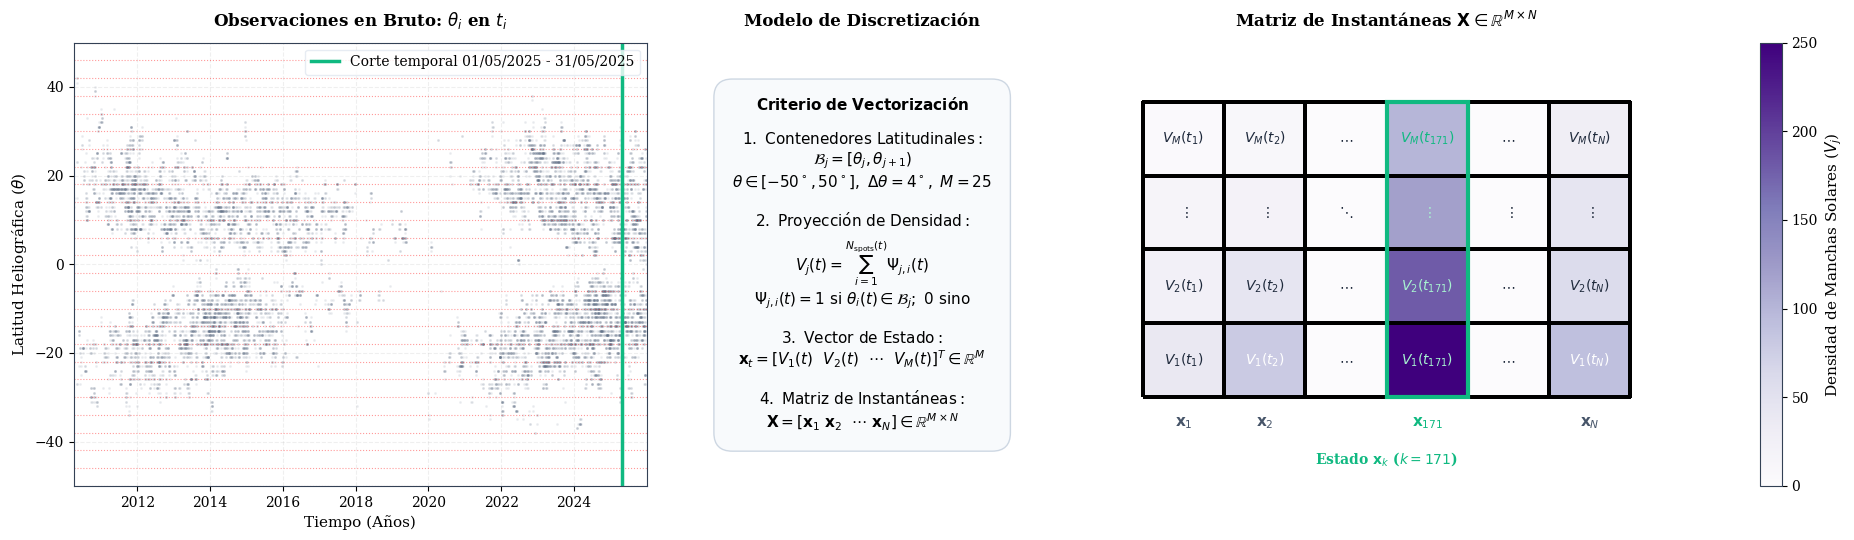

In [221]:
# Contraste Visual en Tres Paneles: Datos en Bruto vs. Matriz Discretizada (rango completo hasta 2025)
import matplotlib.patches as patches

df['year_float_raw'] = df['date'].dt.year + (df['date'].dt.month - 1) / 12 + df['date'].dt.day / 365.25
df_plot = df
monthly_hist_plot = monthly_hist
N_plot = len(monthly_hist_plot)
snapshots_plot = snapshots

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), gridspec_kw={'width_ratios': [1, 0.7, 1.4]})

# Left Panel
axes[0].scatter(df_plot['year_float_raw'], df_plot['lat'], s=1.5, color=COLORS['obs'], alpha=0.08)

for lat_bin in lat_bins:
    axes[0].axhline(y=lat_bin, color='red', linestyle=':', linewidth=0.8, alpha=0.4)

t_values = monthly_hist_plot['year_float'].values
t0 = 2025.333333  # Corte temporal de mayo de 2025
idx_t0 = (np.abs(t_values - t0)).argmin()
t0_actual = t_values[idx_t0]

axes[0].axvline(x=t0_actual, color=COLORS['kalman'], linestyle='-', linewidth=2.5, label='Corte temporal 01/05/2025 - 31/05/2025')
axes[0].set_title(r"Observaciones en Bruto: $\theta_i$ en $t_i$", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Tiempo (Años)", fontsize=11)
axes[0].set_ylabel(r"Latitud Heliográfica ($\theta$)", fontsize=11)
axes[0].set_xlim(df_plot['year_float_raw'].min(), df_plot['year_float_raw'].max())
axes[0].set_ylim(-50, 50)
axes[0].grid(True, linestyle='--', alpha=0.2)
axes[0].legend(loc='upper right')

# Middle Panel: LaTeX math equations
axes[1].axis('off')
eq_text = (
    r"$\mathbf{Criterio\ de\ Vectorización}$" + "\n\n" +
    r"$\mathrm{1.\ Contenedores\ Latitudinales:}$" + "\n" +
    r"$\mathcal{B}_j = [\theta_j, \theta_{j+1})$" + "\n" +
    r"$\theta \in [-50^\circ, 50^\circ], \ \Delta\theta = 4^\circ, \ M = 25$" + "\n\n" +
    r"$\mathrm{2.\ Proyecci\acute{o}n\ de\ Densidad:}$" + "\n" +
    r"$V_j(t) = \sum_{i=1}^{N_{\mathrm{spots}}(t)} \Psi_{j,i}(t)$" + "\n" +
    r"$\Psi_{j,i}(t) = 1 \ \mathrm{si} \ \theta_i(t) \in \mathcal{B}_j; \ 0 \ \mathrm{sino}$" + "\n\n" +
    r"$\mathrm{3.\ Vector\ de\ Estado:}$" + "\n" +
    r"$\mathbf{x}_t = [V_1(t) \ \ V_2(t) \ \ \cdots \ \ V_M(t)]^T \in \mathbb{R}^M$" + "\n\n" +
    r"$\mathrm{4.\ Matriz\ de\ Instant\acute{a}neas:}$" + "\n" +
    r"$\mathbf{X} = [\mathbf{x}_1 \ \mathbf{x}_2 \ \ \cdots \ \mathbf{x}_N] \in \mathbb{R}^{M \times N}$"
)
axes[1].text(0.5, 0.5, eq_text, fontsize=11, ha='center', va='center', 
             bbox=dict(boxstyle="round,pad=1.2", facecolor='#f8fafc', edgecolor='#cbd5e1', alpha=0.95))
axes[1].set_title("Modelo de Discretización", fontsize=12, fontweight='bold', pad=12)

# Right Panel: Matrix table
axes[2].set_xlim(-0.8, 6.8)
axes[2].set_ylim(-1.2, 4.8)
axes[2].set_xticks([])
axes[2].set_yticks([])
for spine in axes[2].spines.values():
    spine.set_visible(False)
axes[2].set_title(r"Matriz de Instantáneas $\mathbf{X} \in \mathbb{R}^{M \times N}$", fontsize=12, fontweight='bold', pad=12)

# Row 0: V1 (bottom), Row 3: VM (top)
cell_values_s1 = np.array([
    [40, 80, 0, 250, 0, 90],  # row 0 (V1)
    [25, 45, 0, 180, 0, 60],  # row 1 (V2)
    [15, 20, 0, 120, 0, 45],  # row 2 (dots)
    [5,  10, 0, 100, 0, 30]   # row 3 (VM)
])

x_bounds = np.arange(7)
y_bounds = np.arange(5)
im = axes[2].pcolormesh(x_bounds, y_bounds, cell_values_s1, cmap='Purples', edgecolors='black', linewidths=1.5, shading='flat')

xs = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

for r in range(4):
    y_coord = r + 0.5
    for c in range(6):
        if r == 0: row_lbl = "1"
        elif r == 1: row_lbl = "2"
        elif r == 2: row_lbl = ""
        else: row_lbl = "M"
        
        if c == 0: txt = r"$V_{" + row_lbl + "}(t_1)$"
        elif c == 1: txt = r"$V_{" + row_lbl + "}(t_2)$"
        elif c == 2: txt = r"$\cdots$"
        elif c == 3: txt = r"$V_{" + row_lbl + "}(t_{171})$"
        elif c == 4: txt = r"$\cdots$"
        else: txt = r"$V_{" + row_lbl + "}(t_N)$"
        
        if r == 2:
            if c in [0, 1, 3, 4, 5]: txt = r"$\vdots$"
            else: txt = r"$\ddots$"
            
        val = cell_values_s1[r, c]
        if c == 3:
            txt_color = '#10b981' if val <= 100 else '#a7f3d0'
        else:
            txt_color = 'white' if val > 75 else '#1e293b'
            
        axes[2].text(xs[c], y_coord, txt, fontsize=10, ha='center', va='center', color=txt_color, fontweight='bold' if c==3 else 'normal')

# Column base labels
axes[2].text(xs[0], -0.35, r"$\mathbf{x}_1$", fontsize=11, ha='center', va='center', color='#475569')
axes[2].text(xs[1], -0.35, r"$\mathbf{x}_2$", fontsize=11, ha='center', va='center', color='#475569')
axes[2].text(xs[3], -0.35, r"$\mathbf{x}_{171}$", fontsize=11, ha='center', va='center', color=COLORS['kalman'], fontweight='bold')
axes[2].text(xs[5], -0.35, r"$\mathbf{x}_N$", fontsize=11, ha='center', va='center', color='#475569')

# Highlight column k=171 in green
rect = patches.Rectangle((3, 0), 1, 4, linewidth=3, edgecolor=COLORS['kalman'], facecolor='none', linestyle='-')
axes[2].add_patch(rect)

cbar = fig.colorbar(im, ax=axes[2], pad=0.08)
cbar.set_label(r"Densidad de Manchas Solares ($V_j$)", fontsize=11)

axes[2].text(3.0, -0.9, r"Estado $\mathbf{x}_k$ ($k=171$)", fontsize=10, ha='center', color=COLORS['kalman'], fontweight='bold')

plt.tight_layout()
plt.show()


## 2. Dynamic Mode Decomposition (DMD) Formalism

DMD seeks the best linear operator $\mathbf{A}$ that maps a latitudinal state vector to its successor in time. Given a collection of $N$ observations, we define the snapshot matrices:

$$\mathbf{X}_1 = [\mathbf{x}_1, \dots, \mathbf{x}_{N-1}], \quad \mathbf{X}_2 = [\mathbf{x}_2, \dots, \mathbf{x}_N]$$

We compute the truncated Singular Value Decomposition (SVD) of $\mathbf{X}_1 \approx \mathbf{U}_r \boldsymbol{\Sigma}_r \mathbf{V}_r^H$. The operator is analyzed through the following steps:

1. **Projection**: The state $\mathbf{x}_k$ is projected into a reduced-order state $\tilde{\mathbf{x}}_k = \mathbf{U}_r^H \mathbf{x}_k \in \mathbb{R}^r$.
2. **Reduced Dynamics**: The evolution in the POD subspace is $\tilde{\mathbf{x}}_{k+1} = \tilde{\mathbf{A}} \tilde{\mathbf{x}}_k$, where $\tilde{\mathbf{A}} = \mathbf{U}_r^H \mathbf{X}_2 \mathbf{V}_r \boldsymbol{\Sigma}_r^{-1}$.
3. **Operator Reconstruction**: The full rank-$r$ mapping $\mathbf{A}$ is reconstructed in the original coordinates:
   $$\mathbf{A} \approx \mathbf{X}_2 \mathbf{V}_r \boldsymbol{\Sigma}_r^{-1} \mathbf{U}_r^H$$

This mathematical framework enables the model to both **reconstruct historical dynamics** (via one-step ahead predictions $\hat{\mathbf{x}}_k = \mathbf{A} \mathbf{x}_{k-1}$ for $k \leq N$) and **project future activity** (via iterative forecasting $\mathbf{x}_{k+1} = \mathbf{A} \mathbf{x}_k$ for $k > N$).


In [222]:
X1, X2 = snapshots[:, :-1], snapshots[:, 1:]
U, S, Vh = svd(X1, full_matrices=False)
r = 10
Ur, Sr, Vr = U[:, :r], np.diag(S[:r]), Vh[:r, :].T
A = X2 @ Vr @ np.linalg.inv(Sr) @ Ur.T

HORIZON = 60
dmd_ssn_raw, butterfly_dots = [], []

for t in range(len(monthly_hist)):
    pred_v = snapshots[:, 0] if t == 0 else A @ snapshots[:, t-1]
    pred_v = np.maximum(0, pred_v)
    dmd_ssn_raw.append(np.sum(pred_v))
    if t % 2 == 0:
        for l in range(len(lat_bins)-1):
            if pred_v[l] > 0.5:
                butterfly_dots.append({'y': monthly_hist['year_float'].iloc[t], 'l': lat_bins[l]+2, 's': pred_v[l], 'is_f': False})

curr_v = snapshots[:, -1]
future_yf = [monthly_hist['year_float'].max() + (i+1)/12 for i in range(HORIZON)]
for t in range(HORIZON):
    curr_v = np.maximum(0, (A @ curr_v) * 0.98)
    dmd_ssn_raw.append(np.sum(curr_v))
    if t % 2 == 0:
        for l in range(len(lat_bins)-1):
            if curr_v[l] > 0.5:
                butterfly_dots.append({'y': future_yf[t], 'l': lat_bins[l]+2, 's': curr_v[l], 'is_f': True})

butterfly_df = pd.DataFrame(butterfly_dots)

### 2.2. Construcción de Matrices de Instantáneas y Diagrama de Flujo del Algoritmo DMD

Para visualizar el formalismo de descomposición dinámica de modos (DMD), representamos el proceso de partición de datos y el flujo de proyección a dimensión reducida:

* **Construcción de Matrices (Izquierda):** Representación visual de cómo la matriz de instantáneas $\mathbf{X}$ (con celdas coloreadas en un gradiente) se divide en las submatrices $\mathbf{X}_1$ (enmarcada en azul en el lado izquierdo de las columnas 1 a $N-1$) y $\mathbf{X}_2$ (enmarcada en púrpura en el lado derecho de las columnas 2 a $N$). La fórmula general de $\mathbf{X}$ se indica arriba de la matriz, mientras que las de $\mathbf{X}_1$ y $\mathbf{X}_2$ se colocan en la base.
* **Estructura de Reducción de Orden (Centro):** Diagrama conmutativo que muestra el paso del espacio físico de alta dimensión $\mathbf{x}_k \in \mathbb{R}^M$ al subespacio POD reducido $\tilde{\mathbf{x}}_k \in \mathbb{R}^r$ vía la matriz $\mathbf{U}_r^T$, la evolución temporal vía $\tilde{\mathbf{A}}$, y la reconstrucción final al espacio físico para obtener el sucesor estimado $\hat{\mathbf{x}}_{k+1}$ usando $\mathbf{U}_r$.
* **Formulación Matemática (Derecha):** Los pasos algebraicos secuenciales en código LaTeX del algoritmo de cálculo partiendo del SVD truncado.


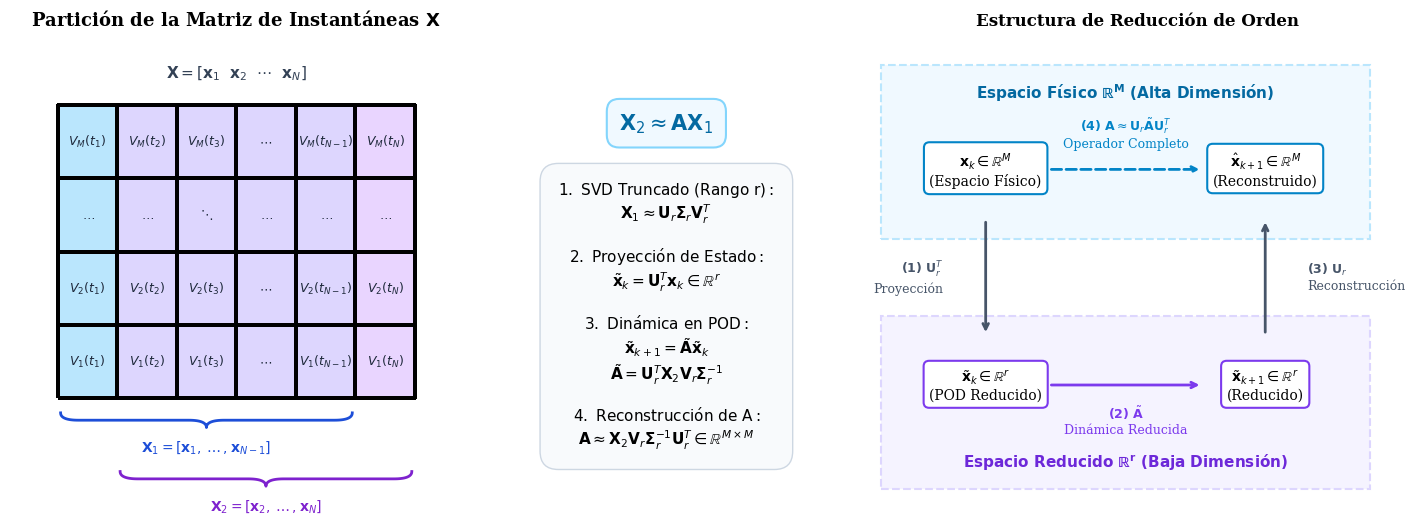

In [223]:
# Visualización en Tres Paneles: Matrices X1/X2, Diagrama Conmutativo y Fórmulas DMD
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

def draw_brace(ax, x1, x2, y, h, color, linewidth=2):
    r = min(0.3, (x2 - x1) * 0.08)
    xmid = (x1 + x2) / 2
    t = np.linspace(0, 1, 20)
    
    cx1 = (1-t)**2 * x1 + 2*(1-t)*t * x1 + t**2 * (x1 + r)
    cy1 = (1-t)**2 * y + 2*(1-t)*t * (y - h/2) + t**2 * (y - h/2)
    lx1 = np.array([x1 + r, xmid - r])
    ly1 = np.array([y - h/2, y - h/2])
    cx2 = (1-t)**2 * (xmid - r) + 2*(1-t)*t * xmid + t**2 * xmid
    cy2 = (1-t)**2 * (y - h/2) + 2*(1-t)*t * (y - h/2) + t**2 * (y - h)
    cx3 = (1-t)**2 * xmid + 2*(1-t)*t * xmid + t**2 * (xmid + r)
    cy3 = (1-t)**2 * (y - h) + 2*(1-t)*t * (y - h/2) + t**2 * (y - h/2)
    lx2 = np.array([xmid + r, x2 - r])
    ly2 = np.array([y - h/2, y - h/2])
    cx4 = (1-t)**2 * (x2 - r) + 2*(1-t)*t * x2 + t**2 * x2
    cy4 = (1-t)**2 * (y - h/2) + 2*(1-t)*t * (y - h/2) + t**2 * y
    
    x_all = np.concatenate([cx1, lx1, cx2, cx3, lx2, cx4])
    y_all = np.concatenate([cy1, ly1, cy2, cy3, ly2, cy4])
    
    ax.plot(x_all, y_all, color=color, linewidth=linewidth)

fig, axes = plt.subplots(1, 3, figsize=(18.0, 6.0), gridspec_kw={'width_ratios': [1.1, 0.78, 1.30]})

# Panel 1 (Izquierdo): Matriz X
axes[0].set_xlim(-0.8, 6.8)
axes[0].set_ylim(-1.5, 4.8)
axes[0].set_xticks([])
axes[0].set_yticks([])
for spine in axes[0].spines.values():
    spine.set_visible(False)
axes[0].set_title(r"Partición de la Matriz de Instantáneas $\mathbf{X}$", fontsize=13, fontweight='bold', pad=15)

cmap_custom = ListedColormap(['#bae6fd', '#ddd6fe', '#e9d5ff'])
cell_values_s2 = np.zeros((4, 6))
cell_values_s2[:, 0] = 0
cell_values_s2[:, 1:5] = 1
cell_values_s2[:, 5] = 2

x_bounds = np.arange(7)
y_bounds = np.arange(5)
im = axes[0].pcolormesh(x_bounds, y_bounds, cell_values_s2, cmap=cmap_custom, edgecolor='black', linewidths=1.5, shading='flat')

xs = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
for r in range(4):
    y_coord = r + 0.5
    if r == 0: row_lbl = "1"
    elif r == 1: row_lbl = "2"
    elif r == 2: row_lbl = ""
    else: row_lbl = "M"
    
    for c in range(6):
        if c == 0: txt = r"$V_{" + row_lbl + "}(t_1)$"
        elif c == 1: txt = r"$V_{" + row_lbl + "}(t_2)$"
        elif c == 2: txt = r"$V_{" + row_lbl + "}(t_3)$"
        elif c == 3: txt = r"$\cdots$"
        elif c == 4: txt = r"$V_{" + row_lbl + "}(t_{N-1})$"
        else: txt = r"$V_{" + row_lbl + "}(t_N)$"
        
        if r == 2:
            if c in [0, 1, 3, 4, 5]: txt = r"$\dots$"
            else: txt = r"$\ddots$"
            
        axes[0].text(xs[c], y_coord, txt, fontsize=9, ha='center', va='center', color='#1e293b')

axes[0].text(3.0, 4.3, r"$\mathbf{X} = [\mathbf{x}_1 \ \ \mathbf{x}_2 \ \ \cdots \ \ \mathbf{x}_N]$", fontsize=11, fontweight='bold', ha='center', va='bottom', color='#334155')

draw_brace(axes[0], 0.05, 4.95, -0.2, 0.2, color='#1d4ed8', linewidth=2.0)
axes[0].text(2.5, -0.55, r"$\mathbf{X}_1 = [\mathbf{x}_1, \dots, \mathbf{x}_{N-1}]$", fontsize=10, fontweight='bold', ha='center', va='top', color='#1d4ed8')

draw_brace(axes[0], 1.05, 5.95, -1.0, 0.2, color='#7e22ce', linewidth=2.0)
axes[0].text(3.5, -1.35, r"$\mathbf{X}_2 = [\mathbf{x}_2, \dots, \mathbf{x}_N]$", fontsize=10, fontweight='bold', ha='center', va='top', color='#7e22ce')

# Panel 2 (Middle): Formulaciones Matemáticas
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_xlim(0, 1)
axes[1].axis('off')

# Highlight objective with its own separated box and larger font
axes[1].text(0.5, 0.90, r"$\mathbf{X}_2 \approx \mathbf{A} \mathbf{X}_1$", 
             fontsize=15, ha='center', va='center', color='#0369a1', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.6", facecolor='#f0f9ff', edgecolor='#7dd3fc', linewidth=1.5, alpha=0.95))

eq_text = (
    r"$\mathrm{1.\ SVD\ Truncado\ (Rango\ r):}$" + "\n" +
    r"$\mathbf{X}_1 \approx \mathbf{U}_r \boldsymbol{\Sigma}_r \mathbf{V}_r^T$" + "\n\n" +
    r"$\mathrm{2.\ Proyecci\acute{o}n\ de\ Estado:}$" + "\n" +
    r"$\tilde{\mathbf{x}}_k = \mathbf{U}_r^T \mathbf{x}_k \in \mathbb{R}^r$" + "\n\n" +
    r"$\mathrm{3.\ Din\acute{a}mica\ en\ POD:}$" + "\n" +
    r"$\tilde{\mathbf{x}}_{k+1} = \tilde{\mathbf{A}} \tilde{\mathbf{x}}_k$" + "\n" +
    r"$\tilde{\mathbf{A}} = \mathbf{U}_r^T \mathbf{X}_2 \mathbf{V}_r \boldsymbol{\Sigma}_r^{-1}$" + "\n\n" +
    r"$\mathrm{4.\ Reconstrucci\acute{o}n\ de\ A:}$" + "\n" +
    r"$\mathbf{A} \approx \mathbf{X}_2 \mathbf{V}_r \boldsymbol{\Sigma}_r^{-1} \mathbf{U}_r^T \in \mathbb{R}^{M \times M}$"
)

axes[1].text(0.5, 0.40, eq_text, fontsize=11, ha='center', va='center', 
             bbox=dict(boxstyle="round,pad=1.2", facecolor='#f8fafc', edgecolor='#cbd5e1', alpha=0.95))
#axes[1].set_title("Algoritmo DMD & SVD", fontsize=12, fontweight='bold', pad=15)

# Panel 3 (Right): Estructura de Reducción de Orden
axes[2].set_xlim(-0.08, 1.45)
axes[2].set_ylim(-0.10, 1.10)
axes[2].axis('off')
axes[2].set_title("Estructura de Reducción de Orden", fontsize=12, fontweight='bold', pad=15)

rect_rm = patches.Rectangle((-0.05, 0.60), 1.40, 0.45, facecolor='#f0f9ff', edgecolor='#bae6fd', linestyle='--', linewidth=1.5, zorder=0)
rect_rr = patches.Rectangle((-0.05, -0.05), 1.40, 0.45, facecolor='#f5f3ff', edgecolor='#ddd6fe', linestyle='--', linewidth=1.5, zorder=0)
axes[2].add_patch(rect_rm)
axes[2].add_patch(rect_rr)

axes[2].text(0.65, 0.98, r"$\mathbf{Espacio\ F\acute{\iota}sico\ \mathbb{R}^M\ (Alta\ Dimensi\acute{o}n)}$", fontsize=11, fontweight='bold', ha='center', va='center', color='#0369a1', zorder=2)
axes[2].text(0.65, 0.02, r"$\mathbf{Espacio\ Reducido\ \mathbb{R}^r\ (Baja\ Dimensi\acute{o}n)}$", fontsize=11, fontweight='bold', ha='center', va='center', color='#6d28d9', zorder=2)

box_high = dict(boxstyle="round,pad=0.4", facecolor='#ffffff', edgecolor='#0284c7', linewidth=1.5)
box_low = dict(boxstyle="round,pad=0.4", facecolor='#ffffff', edgecolor='#7c3aed', linewidth=1.5)

x_left = 0.25
x_right = 1.05
y_high = 0.78
y_low = 0.22

axes[2].text(x_left, y_high, r"$\mathbf{x}_k \in \mathbb{R}^M$" + "\n" + "(Espacio Físico)", ha='center', va='center', bbox=box_high, fontsize=10, zorder=2)
axes[2].text(x_right, y_high, r"$\hat{\mathbf{x}}_{k+1} \in \mathbb{R}^M$" + "\n" + "(Reconstruido)", ha='center', va='center', bbox=box_high, fontsize=10, zorder=2)
axes[2].text(x_left, y_low, r"$\tilde{\mathbf{x}}_k \in \mathbb{R}^r$" + "\n" + "(POD Reducido)", ha='center', va='center', bbox=box_low, fontsize=10, zorder=2)
axes[2].text(x_right, y_low, r"$\tilde{\mathbf{x}}_{k+1} \in \mathbb{R}^r$" + "\n" + "(Reducido)", ha='center', va='center', bbox=box_low, fontsize=10, zorder=2)

axes[2].annotate("", xy=(x_left, 0.35), xytext=(x_left, 0.65), arrowprops=dict(arrowstyle="->", lw=2, color='#475569'), zorder=2)
axes[2].text(x_left - 0.12, 0.50, r"$\mathbf{(1)\ U}_r^T$" + "\n" + "Proyección", ha='right', va='center', fontsize=9, color='#475569', zorder=2)

axes[2].annotate("", xy=(x_right, 0.65), xytext=(x_right, 0.35), arrowprops=dict(arrowstyle="->", lw=2, color='#475569'), zorder=2)
axes[2].text(x_right + 0.12, 0.50, r"$\mathbf{(3)\ U}_r$" + "\n" + "Reconstrucción", ha='left', va='center', fontsize=9, color='#475569', zorder=2)

axes[2].annotate("", xy=(x_right - 0.18, y_low), xytext=(x_left + 0.18, y_low), arrowprops=dict(arrowstyle="->", lw=2, color='#7c3aed'), zorder=2)
axes[2].text(0.65, y_low - 0.05, r"$\mathbf{(2)\ }\tilde{\mathbf{A}}$" + "\n" + "Dinámica Reducida", ha='center', va='top', fontsize=9, color='#7c3aed', zorder=2)

axes[2].annotate("", xy=(x_right - 0.18, y_high), xytext=(x_left + 0.18, y_high), arrowprops=dict(arrowstyle="->", lw=2, linestyle='--', color='#0284c7'), zorder=2)
axes[2].text(0.65, y_high + 0.05, r"$\mathbf{(4)\ A} \approx \mathbf{U}_r \tilde{\mathbf{A}} \mathbf{U}_r^T$" + "\n" + "Operador Completo", ha='center', va='bottom', fontsize=9, color='#0284c7', zorder=2)

plt.subplots_adjust(wspace=0.1)
plt.show()


## 3. Discrete Integral and Scaling (DMD SSN)

The total activity, or DMD-reconstructed Sunspot Number ($SSN_{DMD}$), is obtained by integrating the predicted latitudinal density vector $\hat{\mathbf{x}}_t = [\hat{V}_1(t), \dots, \hat{V}_M(t)]^T$:

$$SSN_{DMD}(t) = \kappa \cdot \sum_{j=1}^M \hat{V}_j(t)$$

The scaling factor $\kappa$ serves as a calibration constant to map the integrated latitudinal counts back to the standard SSN scale. It is computed to minimize bias across the historical record:

$$\kappa = \frac{\sum_{t=1}^N SSN_{obs}(t)}{\sum_{t=1}^N \left( \sum_{j=1}^M \hat{V}_j(t) \right)}$$


In [224]:
kappa = np.sum(monthly_hist['ssn']) / np.sum(dmd_ssn_raw[:len(monthly_hist)])
dmd_ssn = np.array(dmd_ssn_raw) * kappa

## 4. PVL Parametric Model & Adaptive Kalman Filter

To forecast the Sunspot Number (SSN) as a global time series, we combine the **Podladchikova-Van der Linden (PVL)** parametric model with an adaptive Kalman Filter. 

### 4.1. The PVL Cycle Shape
The PVL model (2012) provides a heuristic "skeleton" for the solar cycle. The shape function $f(v)$ is defined as:

$$f(v; a, b) = \frac{a \cdot v^3}{\exp(v^2/b^2) - 0.71}$$

where $v$ is the time in months from cycle onset. The parameters $a$ and $b$ are linked via the power-law: $b = 27.12 + 25.15 \cdot (1000 a)^{-1/4}$. The amplitude $a$ is calibrated iteratively to match a target maximum SSN.

### 4.2. Adaptive Kalman Filter Formalism
We use the PVL curve to guide the state transition of a Kalman Filter. The predicted global activity trend, **$SSN_{PVLK}$**, is defined as the updated state of the filter:

$$SSN_{PVLK}(t) = \hat{x}_k$$

The recursive equations are:
$$\hat{x}_k^- = \Phi_k \hat{x}_{k-1}, \quad \hat{x}_k = \hat{x}_k^- + K_k (z_k - \hat{x}_k^-)$$

where $\Phi_k = f(v_k)/f(v_{k-1})$ and $K_k$ is the Kalman gain. Adaptive noise scaling is employed to account for heteroscedasticity ($Q_k = 0.2 \hat{x}_k^-$, $R_k = 2.5 \hat{x}_k^-$).


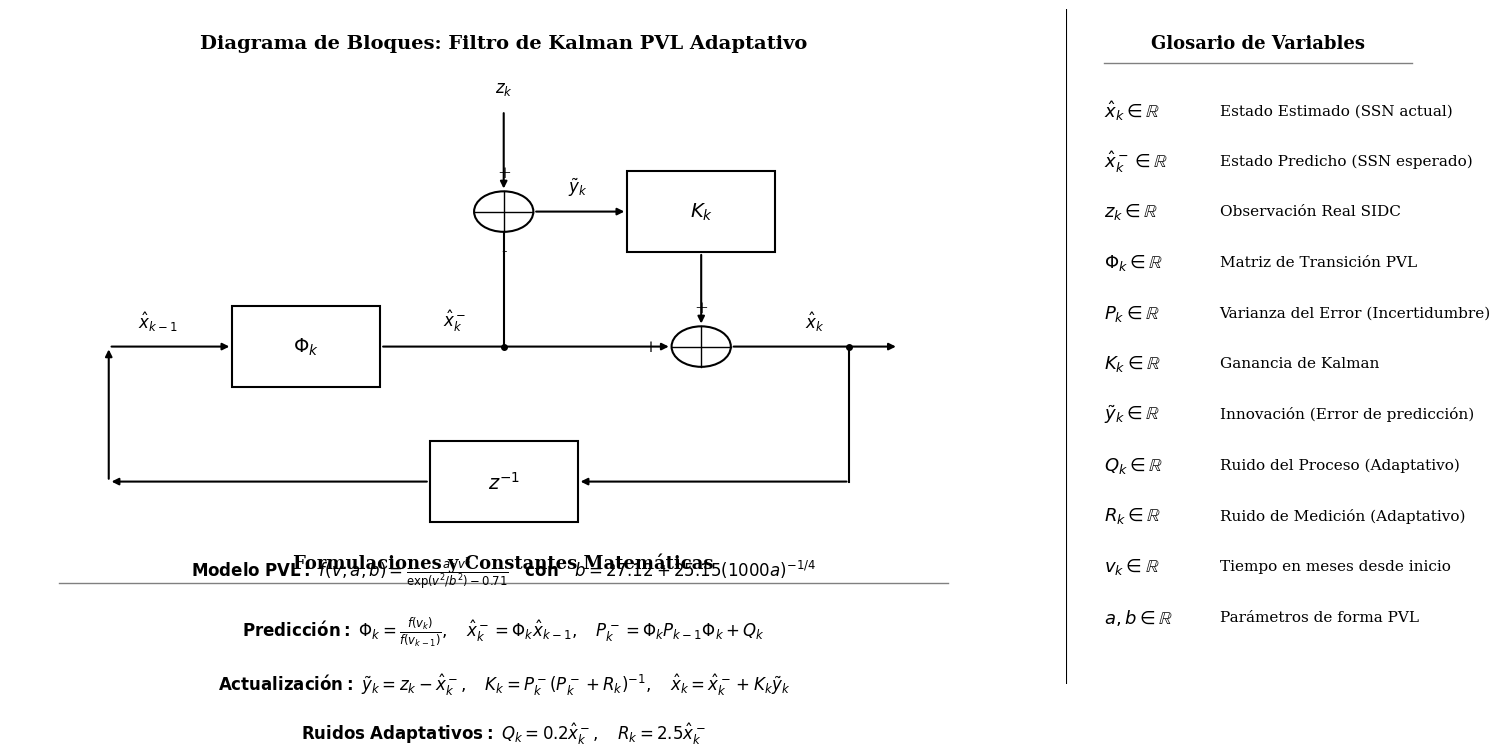

In [225]:
# Diagrama del Modelo Paramétrico y Filtro de Kalman Adaptativo (Teoría de Control)
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), gridspec_kw={'width_ratios': [1.8, 0.7]}, facecolor='white')

# =========================================================
# PANEL 1: Diagrama de Bloques (Teoría de Control)
# =========================================================
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')

ax1.text(5, 9.5, "Diagrama de Bloques: Filtro de Kalman PVL Adaptativo", ha='center', va='center', fontsize=14, fontweight='bold', color='black')

# Helper function to draw blocks
def draw_block(ax, center_x, center_y, width, height, text):
    rect = patches.Rectangle((center_x - width/2, center_y - height/2), width, height, facecolor='white', edgecolor='black', lw=1.5)
    ax.add_patch(rect)
    ax.text(center_x, center_y, text, ha='center', va='center', fontsize=14, color='black', fontweight='bold')

def draw_sum(ax, center_x, center_y, label1, pos1, label2, pos2):
    circle = patches.Circle((center_x, center_y), 0.3, facecolor='white', edgecolor='black', lw=1.5)
    ax.add_patch(circle)
    # Draw cross
    ax.plot([center_x-0.3, center_x+0.3], [center_y, center_y], color='black', lw=1.0)
    ax.plot([center_x, center_x], [center_y-0.3, center_y+0.3], color='black', lw=1.0)
    
    # Add signs
    if pos1 == 'left': ax.text(center_x-0.45, center_y, label1, ha='right', va='center', fontsize=12)
    elif pos1 == 'top': ax.text(center_x, center_y+0.45, label1, ha='center', va='bottom', fontsize=12)
    elif pos1 == 'bottom': ax.text(center_x, center_y-0.45, label1, ha='center', va='top', fontsize=12)
    
    if pos2 == 'left': ax.text(center_x-0.45, center_y, label2, ha='right', va='center', fontsize=12)
    elif pos2 == 'top': ax.text(center_x, center_y+0.45, label2, ha='center', va='bottom', fontsize=12)
    elif pos2 == 'bottom': ax.text(center_x, center_y-0.45, label2, ha='center', va='top', fontsize=12)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", lw=1.5, color='black'))

# Blocks
draw_block(ax1, 3, 5, 1.5, 1.2, r"$\Phi_k$") # State Transition
draw_block(ax1, 7, 7, 1.5, 1.2, r"$K_k$")    # Kalman Gain
draw_block(ax1, 5, 3, 1.5, 1.2, r"$z^{-1}$") # Delay

# Summing junctions
draw_sum(ax1, 5, 7, "+", "top", "-", "bottom") # Innovation sum
draw_sum(ax1, 7, 5, "+", "top", "+", "left")   # Update sum

# Lines and Arrows
# Delay up to line
draw_arrow(ax1, 1, 3, 1, 5)
draw_arrow(ax1, 1, 5, 2.25, 5)
ax1.text(1.5, 5.2, r"$\hat{x}_{k-1}$", ha='center', va='bottom', fontsize=12)

# Phi to junction 2
draw_arrow(ax1, 3.75, 5, 6.7, 5)
ax1.text(4.5, 5.2, r"$\hat{x}_k^-$", ha='center', va='bottom', fontsize=12)

# Split from Phi to junction 1 (Innovation)
ax1.plot([5, 5], [5, 6.7], color='black', lw=1.5)
ax1.plot(5, 5, marker='o', markersize=4, color='black') # Split dot

# Measurement zk to junction 1
draw_arrow(ax1, 5, 8.5, 5, 7.3)
ax1.text(5, 8.7, r"$z_k$", ha='center', va='bottom', fontsize=12)

# Junction 1 to Gain
draw_arrow(ax1, 5.3, 7, 6.25, 7)
ax1.text(5.75, 7.2, r"$\tilde{y}_k$", ha='center', va='bottom', fontsize=12)

# Gain to Junction 2
draw_arrow(ax1, 7, 6.4, 7, 5.3)

# Junction 2 to Output
draw_arrow(ax1, 7.3, 5, 9, 5)
ax1.text(8.15, 5.2, r"$\hat{x}_k$", ha='center', va='bottom', fontsize=12)

# Feedback loop
ax1.plot([8.5, 8.5], [5, 3], color='black', lw=1.5)
ax1.plot(8.5, 5, marker='o', markersize=4, color='black') # Split dot
draw_arrow(ax1, 8.5, 3, 5.75, 3)
draw_arrow(ax1, 4.25, 3, 1, 3)

# --- Formulaciones Matemáticas (Abajo) ---
ax1.text(5, 1.8, "Formulaciones y Constantes Matemáticas", ha='center', va='center', fontsize=13, fontweight='bold', color='black')
ax1.plot([0.5, 9.5], [1.5, 1.5], color='gray', lw=1.0, linestyle='-')

eq_text = (
    r"$\mathbf{Modelo\ PVL:}\ f(v; a, b) = \frac{a \cdot v^3}{\exp(v^2/b^2) - 0.71} \quad \mathbf{con} \quad b = 27.12 + 25.15(1000a)^{-1/4}$" + "\n\n" +
    r"$\mathbf{Predicci\acute{o}n:}\ \Phi_k = \frac{f(v_k)}{f(v_{k-1})}, \quad \hat{x}_k^- = \Phi_k \hat{x}_{k-1}, \quad P_k^- = \Phi_k P_{k-1} \Phi_k + Q_k$" + "\n\n" +
    r"$\mathbf{Actualizaci\acute{o}n:}\ \tilde{y}_k = z_k - \hat{x}_k^-, \quad K_k = P_k^-(P_k^- + R_k)^{-1}, \quad \hat{x}_k = \hat{x}_k^- + K_k \tilde{y}_k$" + "\n\n" +
    r"$\mathbf{Ruidos\ Adaptativos:}\ Q_k = 0.2 \hat{x}_k^-, \quad R_k = 2.5 \hat{x}_k^-$"
)

ax1.text(5.0, 0.5, eq_text, ha='center', va='center', fontsize=12, color='black')


# =========================================================
# PANEL 2: Glosario de Variables y Dimensiones
# =========================================================
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')

# Separator Line
ax2.plot([0, 0], [0, 10], color='black', lw=1.5)

ax2.text(5, 9.5, "Glosario de Variables", ha='center', va='center', fontsize=13, fontweight='bold', color='black')
ax2.plot([1, 9], [9.2, 9.2], color='gray', lw=1.0, linestyle='-')

# Lista de términos
terms = [
    (r"$\hat{x}_k \in \mathbb{R}$", "Estado Estimado (SSN actual)"),
    (r"$\hat{x}_k^- \in \mathbb{R}$", "Estado Predicho (SSN esperado)"),
    (r"$z_k \in \mathbb{R}$", "Observación Real SIDC"),
    (r"$\Phi_k \in \mathbb{R}$", "Matriz de Transición PVL"),
    (r"$P_k \in \mathbb{R}$", "Varianza del Error (Incertidumbre)"),
    (r"$K_k \in \mathbb{R}$", "Ganancia de Kalman"),
    (r"$\tilde{y}_k \in \mathbb{R}$", "Innovación (Error de predicción)"),
    (r"$Q_k \in \mathbb{R}$", "Ruido del Proceso (Adaptativo)"),
    (r"$R_k \in \mathbb{R}$", "Ruido de Medición (Adaptativo)"),
    (r"$v_k \in \mathbb{R}$", "Tiempo en meses desde inicio"),
    (r"$a, b \in \mathbb{R}$", "Parámetros de forma PVL")
]

y_pos = 8.5
for term, desc in terms:
    ax2.text(1.0, y_pos, term, ha='left', va='center', fontsize=13, fontweight='bold', color='black')
    ax2.text(4.0, y_pos, desc, ha='left', va='center', fontsize=11, color='black')
    y_pos -= 0.75

plt.subplots_adjust(wspace=0.1, top=0.95, bottom=0.05, left=0.05, right=0.95)
plt.show()


In [226]:
def pvl_shape(v, a, b): return (a * (v**3)) / (np.exp((v*v)/(b*b)) - 0.71) if v > 0 else 0.0
a_p, target = 0.01, 140
for _ in range(10): 
    b_p = 27.12 + 25.15 / np.power(a_p * 1000, 0.25)
    a_p *= (target / max(1, pvl_shape(50, a_p, b_p)))
b_p = 27.12 + 25.15 / np.power(a_p * 1000, 0.25)

full_yf = np.concatenate([monthly_hist['year_float'].values, future_yf])
is_f = np.concatenate([np.zeros(len(monthly_hist)), np.ones(HORIZON)]).astype(bool)
def get_v(yf): return max(1, int(round((yf - (2019.9 if yf >= 2019.9 else 2008.9)) * 12)))

kalman_ssn, state_r, state_p = [], monthly_hist['ssn'].iloc[0], 10.0
for yf in full_yf:
    phi = pvl_shape(get_v(yf), a_p, b_p) / max(0.1, pvl_shape(get_v(yf - 1/12), a_p, b_p))
    r_pred = phi * state_r
    state_p = phi**2 * state_p + 0.2 * r_pred
    idx = np.where(monthly_hist['year_float'] == yf)[0]
    if len(idx) > 0:
        k_g = state_p / (state_p + 2.5 * r_pred)
        state_r = r_pred + k_g * (monthly_hist['ssn'].iloc[idx[0]] - r_pred)
        state_p = (1 - k_g) * state_p
    else: state_r = r_pred
    kalman_ssn.append(state_r)

## 5. Temporal Evolution Analysis and Model Comparison

We evaluate the performance of both models by calculating the Mean Absolute Percentage Error (MAPE) against historical observations and generating independent projections. 

The **PVL-Kalman** model ($SSN_{PVLK}$) focuses on optimal scalar tracking, while the **DMD** model ($SSN_{DMD}$) provides a spatio-temporal reconstruction of the butterfly diagram, integrating latitudinal density into a global index.


MAPE PVL-Kalman: 19.68%
MAPE DMD: 32.77%


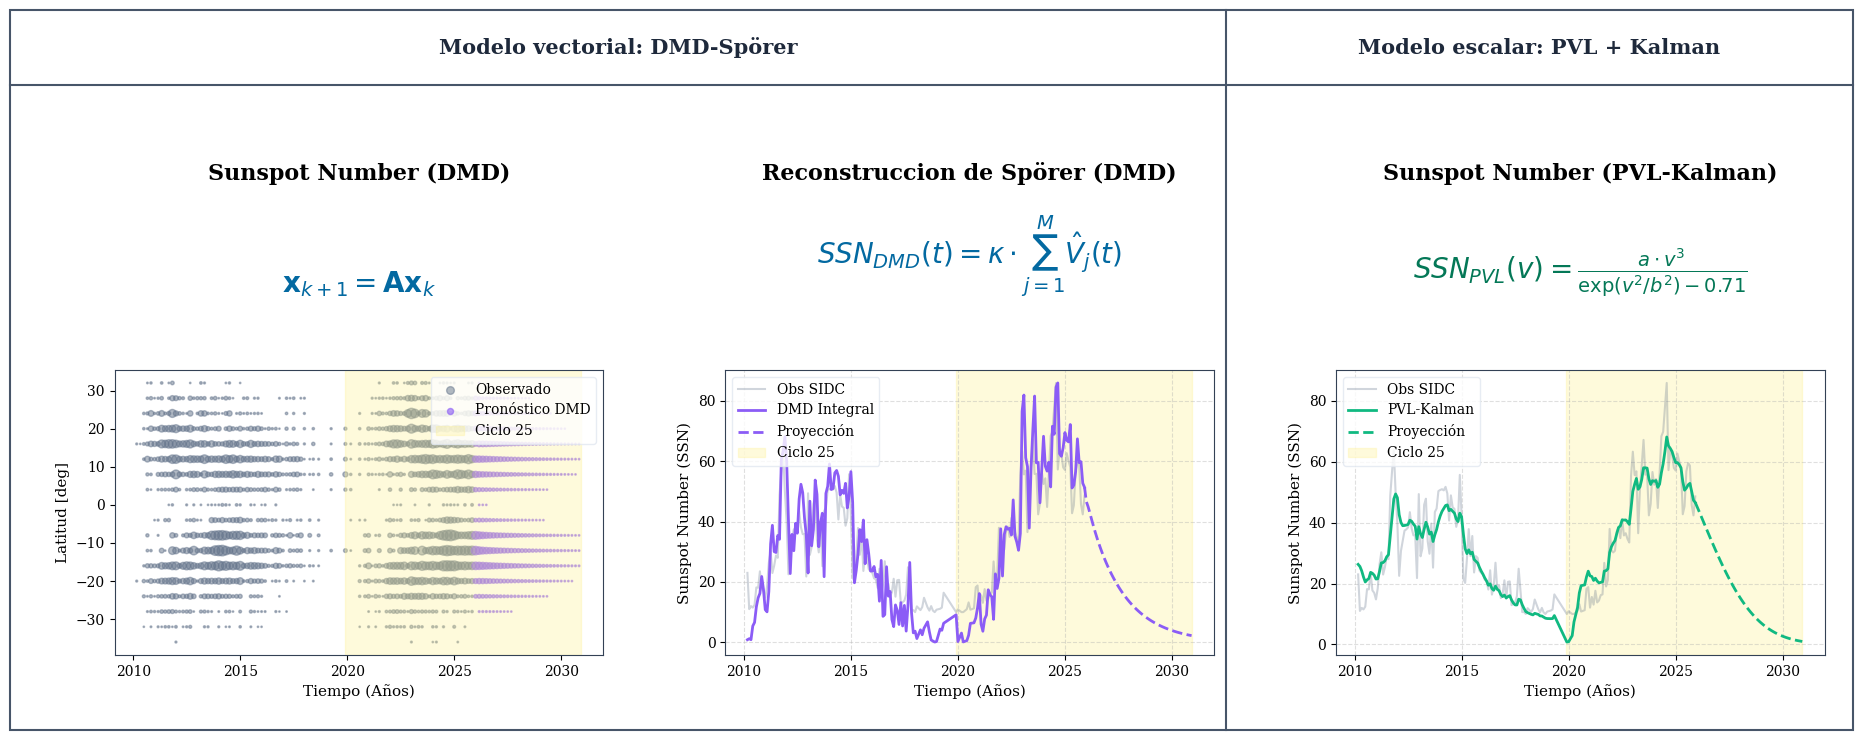

In [227]:
hist_len = len(monthly_hist)
true_ssn = monthly_hist['ssn'].values

# Calculate Relative Errors (MAPE)
kalman_err = np.mean(np.abs(true_ssn - kalman_ssn[:hist_len]) / np.maximum(1, true_ssn)) * 100
dmd_err = np.mean(np.abs(true_ssn - dmd_ssn[:hist_len]) / np.maximum(1, true_ssn)) * 100

print(f"MAPE PVL-Kalman: {kalman_err:.2f}%")
print(f"MAPE DMD: {dmd_err:.2f}%")

# Moderate vertical size: 7.5
fig, axes = plt.subplots(1, 3, figsize=(19, 7.5), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.25})

cycle_25_start = 2019.9

# Panel 1: Spörer Migration
dots = butterfly_df
axes[0].scatter(dots[~dots['is_f']]['y'], dots[~dots['is_f']]['l'], s=dots[~dots['is_f']]['s']*2, c=COLORS['obs'], alpha=0.5, label='Observado')
axes[0].scatter(dots[dots['is_f']]['y'], dots[dots['is_f']]['l'], s=dots[dots['is_f']]['s']*2, c=COLORS['dmd'], alpha=0.6, label='Pronóstico DMD')
axes[0].axvspan(cycle_25_start, full_yf.max(), color='#fef08a', alpha=0.3, label='Ciclo 25')
axes[0].text(0.5, 1.65, "Sunspot Number (DMD)", transform=axes[0].transAxes, ha='center', va='bottom', fontsize=16, fontweight='bold', color='black')
axes[0].text(0.5, 1.25, r"$\mathbf{x}_{k+1} = \mathbf{A} \mathbf{x}_k$", transform=axes[0].transAxes, ha='center', va='bottom', fontsize=20, color='#0369a1')
axes[0].set_xlabel("Tiempo (Años)", fontsize=11)
axes[0].set_ylabel("Latitud [deg]", fontsize=11)
axes[0].legend(loc='upper right', frameon=True)

# Panel 2: SSN DMD
axes[1].plot(monthly_hist['year_float'], true_ssn, color=COLORS['obs'], alpha=0.3, label='Obs SIDC')
axes[1].plot(full_yf[:hist_len], dmd_ssn[:hist_len], color=COLORS['dmd'], lw=2, label='DMD Integral')
axes[1].plot(full_yf[hist_len-1:], dmd_ssn[hist_len-1:], color=COLORS['dmd'], lw=2, ls='--', label='Proyección')
axes[1].axvspan(cycle_25_start, full_yf.max(), color='#fef08a', alpha=0.3, label='Ciclo 25')
axes[1].text(0.5, 1.65, "Reconstruccion de Spörer (DMD)", transform=axes[1].transAxes, ha='center', va='bottom', fontsize=16, fontweight='bold', color='black')
axes[1].text(0.5, 1.25, r"$SSN_{DMD}(t) = \kappa \cdot \sum_{j=1}^M \hat{V}_j(t)$", transform=axes[1].transAxes, ha='center', va='bottom', fontsize=20, color='#0369a1')
axes[1].set_xlabel("Tiempo (Años)", fontsize=11)
axes[1].set_ylabel("Sunspot Number (SSN)", fontsize=11)
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.4)

# Panel 3: SSN PVL-Kalman
axes[2].plot(monthly_hist['year_float'], true_ssn, color=COLORS['obs'], alpha=0.3, label='Obs SIDC')
axes[2].plot(full_yf[:hist_len], kalman_ssn[:hist_len], color=COLORS['kalman'], lw=2, label='PVL-Kalman')
axes[2].plot(full_yf[hist_len-1:], kalman_ssn[hist_len-1:], color=COLORS['kalman'], lw=2, ls='--', label='Proyección')
axes[2].axvspan(cycle_25_start, full_yf.max(), color='#fef08a', alpha=0.3, label='Ciclo 25')
axes[2].text(0.5, 1.65, "Sunspot Number (PVL-Kalman)", transform=axes[2].transAxes, ha='center', va='bottom', fontsize=16, fontweight='bold', color='black')
axes[2].text(0.5, 1.25, r"$SSN_{PVL}(v) = \frac{a \cdot v^3}{\exp(v^2/b^2) - 0.71}$", transform=axes[2].transAxes, ha='center', va='bottom', fontsize=20, color='#047857')
axes[2].set_xlabel("Tiempo (Años)", fontsize=11)
axes[2].set_ylabel("Sunspot Number (SSN)", fontsize=11)
axes[2].legend(loc='upper left')
axes[2].grid(True, linestyle='--', alpha=0.4)

# Draw a sober Excel-like table
import matplotlib.patches as patches
import matplotlib.lines as lines

table_x_min = 0.015
table_x_max = 0.985
table_y_min = 0.02
table_y_max = 0.98
header_y = 0.88
col_sep_x = 0.655

# Outer Box
rect_table = patches.Rectangle((table_x_min, table_y_min), table_x_max - table_x_min, table_y_max - table_y_min, transform=fig.transFigure, facecolor='none', edgecolor='#475569', linewidth=1.5, zorder=0)
fig.patches.append(rect_table)

# Horizontal Header Line
line_h = lines.Line2D((table_x_min, table_x_max), (header_y, header_y), transform=fig.transFigure, color='#475569', linewidth=1.5, zorder=0)
fig.add_artist(line_h)

# Vertical Column Separator
line_v = lines.Line2D((col_sep_x, col_sep_x), (table_y_min, table_y_max), transform=fig.transFigure, color='#475569', linewidth=1.5, zorder=0)
fig.add_artist(line_v)

# Super Titles inside Header
fig.text((table_x_min + col_sep_x)/2, 0.93, "Modelo vectorial: DMD-Spörer", ha='center', va='center', fontsize=15, fontweight='bold', color='#1e293b')
fig.text((col_sep_x + table_x_max)/2, 0.93, "Modelo escalar: PVL + Kalman", ha='center', va='center', fontsize=15, fontweight='bold', color='#1e293b')

# Dramatically lower the top of the axes to exactly 0.5 as requested
plt.subplots_adjust(top=0.50, bottom=0.12, left=0.07, right=0.97)
plt.show()


## 6. Spörer Diagram: Latitudinal Migration Analysis

The Butterfly diagram demonstrates the descent of sunspot production towards the solar equator, modeled via the Koopman Operator.

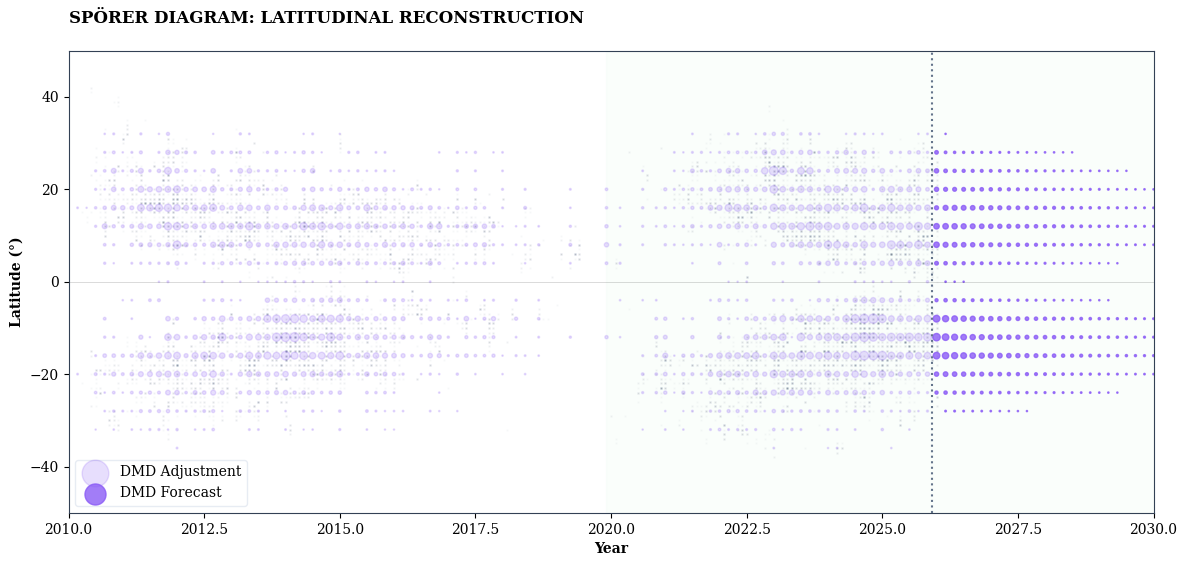

In [228]:
plt.figure(figsize=(14, 6))
plt.scatter(df['date'].dt.year + df['date'].dt.month/12, df['lat'], s=0.5, color=COLORS['obs'], alpha=0.03)
adj = butterfly_df[~butterfly_df['is_f']]
fct = butterfly_df[butterfly_df['is_f']]
plt.scatter(adj['y'], adj['l'], s=adj['s']*1.5, color=COLORS['dmd'], alpha=0.2, label='DMD Adjustment')
plt.scatter(fct['y'], fct['l'], s=fct['s']*1.5, color=COLORS['dmd'], alpha=0.8, label='DMD Forecast')

plt.axvline(monthly_hist['year_float'].max(), color='#64748b', ls=':', lw=1.5)
plt.axvspan(2019.9, full_yf[-1], color=COLORS['future_bg'], alpha=0.3, zorder=-1)
plt.axhline(0, color='black', lw=0.5, alpha=0.2)
plt.title('SPÖRER DIAGRAM: LATITUDINAL RECONSTRUCTION', loc='left', fontweight='bold', pad=20)
plt.ylabel('Latitude (°)', fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.xlim(2010, 2030); plt.ylim(-50, 50)
plt.legend(loc='lower left', markerscale=4, frameon=True)
plt.savefig('figure_sporer_migration.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Comprehensive Performance Metrics for SSN Forecasting

To provide a rigorous evaluation of the predictive models, we calculate several standard error metrics. Let $y_t$ be the observed SSN and $\hat{y}_t$ the predicted value at time $t$.

### 6.1. Metric Formulations

1. **Mean Absolute Error (MAE)**: Measures the average magnitude of errors without considering their direction.
   $$MAE = \frac{1}{N} \sum_{t=1}^N |y_t - \hat{y}_t|$$

2. **Root Mean Squared Error (RMSE)**: Penalizes larger errors more heavily.
   $$RMSE = \sqrt{\frac{1}{N} \sum_{t=1}^N (y_t - \hat{y}_t)^2}$$

3. **Mean Absolute Percentage Error (MAPE)**: Provides a relative measure of error.
   $$MAPE = \frac{100\%}{N} \sum_{t=1}^N \left| \frac{y_t - \hat{y}_t}{y_t} \right|$$

4. **Coefficient of Determination ($R^2$)**: Indicates the proportion of variance explained by the model.
   $$R^2 = 1 - \frac{\sum (y_t - \hat{y}_t)^2}{\sum (y_t - \bar{y})^2}$$

5. **Pearson Correlation ($\rho$)**: Measures the linear correlation between observed and predicted values.
   $$\rho = \frac{\text{cov}(y, \hat{y})}{\sigma_y \sigma_{\hat{y}}}$$


In [229]:
from scipy.stats import pearsonr

def calculate_ssn_metrics(obs, pred, name):
    mask = ~np.isnan(obs) & (obs > 0)
    o, p = obs[mask], pred[mask]
    
    mae = np.mean(np.abs(o - p))
    rmse = np.sqrt(np.mean((o - p)**2))
    mape = np.mean(np.abs((o - p) / o)) * 100
    r2 = 1 - (np.sum((o - p)**2) / np.sum((o - np.mean(o))**2))
    corr, _ = pearsonr(o, p)
    
    return {
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'R2': round(r2, 4),
        'Pearson': round(corr, 4)
    }

obs_ssn = monthly_hist['ssn'].values
metrics_kalman = calculate_ssn_metrics(obs_ssn, np.array(kalman_ssn[:len(obs_ssn)]), 'PVL-Kalman')
metrics_dmd = calculate_ssn_metrics(obs_ssn, dmd_ssn[:len(obs_ssn)], 'DMD')

ssn_metrics_df = pd.DataFrame([metrics_kalman, metrics_dmd])
print("SSN Prediction Metrics:")
display(ssn_metrics_df)

ssn_metrics_df.to_csv('ssn_metrics.csv', index=False)
print("\nResults saved to ssn_metrics.csv")

SSN Prediction Metrics:


,Model,MAE,RMSE,MAPE (%),R2,Pearson
0,PVL-Kalman,4.88,6.36,19.68,0.8685,0.9322
1,DMD,7.91,10.08,32.77,0.6697,0.9071



Results saved to ssn_metrics.csv


## 7. Spatio-Temporal Metrics for Latitudinal Migration (Spörer Diagram)

The Spörer diagram analysis requires metrics that capture the spatial distribution across latitudes over time.

### 7.1. Metric Formulations

1. **Relative Frobenius Error ($E_{F}$)**: Measures the overall reconstruction error of the snapshot matrix $\mathbf{X}$.
   $$E_F = \frac{\|\mathbf{X} - \hat{\mathbf{X}}\|_F}{\|\mathbf{X}\|_F}$$

2. **Spatio-temporal Correlation ($\rho_{ST}$)**: Correlation between the flattened observed and reconstructed snapshot matrices.
   $$\rho_{ST} = \text{corr}(\text{vec}(\mathbf{X}), \text{vec}(\hat{\mathbf{X}}))$$

3. **Mean Latitudinal Center Error (MLCE)**: Average absolute difference between the observed and predicted centroid of sunspot activity.
   $$MLCE = \frac{1}{N} \sum_{t=1}^N |\theta_{c,t} - \hat{\theta}_{c,t}|$$
   where $\theta_{c,t} = \frac{\sum \theta_j V_j(t)}{\sum V_j(t)}$ is the latitudinal center of mass.


In [230]:
# Reconstruction of the historical snapshot matrix
X_obs = snapshots[:, 1:] # X2 in DMD terms
X_pred = np.zeros_like(X_obs)
for t in range(X_obs.shape[1]):
    X_pred[:, t] = np.maximum(0, A @ snapshots[:, t])

# 1. Relative Frobenius Error
frob_error = np.linalg.norm(X_obs - X_pred, 'fro') / np.linalg.norm(X_obs, 'fro')

# 2. Spatio-temporal Correlation
st_corr, _ = pearsonr(X_obs.flatten(), X_pred.flatten())

# 3. Mean Latitudinal Center Error
mid_lats = lat_bins[:-1] + 2
def get_center(v):
    s = np.sum(v)
    return np.sum(v * mid_lats) / s if s > 0 else 0

centers_obs = np.array([get_center(X_obs[:, t]) for t in range(X_obs.shape[1])])
centers_pred = np.array([get_center(X_pred[:, t]) for t in range(X_pred.shape[1])])
mlce = np.mean(np.abs(centers_obs - centers_pred))

sporer_metrics = {
    'Metric': ['Relative Frobenius Error', 'Spatio-temporal Correlation', 'Mean Latitudinal Center Error (deg)'],
    'Value': [round(frob_error, 4), round(st_corr, 4), round(mlce, 2)]
}

sporer_metrics_df = pd.DataFrame(sporer_metrics)
print("Spörer Diagram Performance Metrics:")
display(sporer_metrics_df)

sporer_metrics_df.to_csv('sporer_metrics.csv', index=False)
print("\nResults saved to sporer_metrics.csv")

Spörer Diagram Performance Metrics:


,Metric,Value
0,Relative Frobenius Error,0.5713
1,Spatio-temporal Correlation,0.7722
2,Mean Latitudinal Center Error (deg),5.3800



Results saved to sporer_metrics.csv
